In [1]:
# import external modules
import numpy as np
import os

# Add Exasim to Python search path
cdir = os.getcwd(); ii = cdir.find("Exasim")
exec(open(cdir[0:(ii+6)] + "/install/setpath.py").read())

# import internal modules
import Preprocessing, Postprocessing, Gencode, Mesh
import Utilities, PlotUtilities


==> Exasim frontends ...



In [2]:
outpath = cdir[0:(ii+6)]+"/build/dataout"
inpath = cdir[0:(ii+6)]+"/build/datain"

pde, master, mesh, xdg, udg, vdg, sol = Utilities.retrieveData(inpath,outpath)

mpiprocs = pde['ndims'][0]
p,t = Postprocessing.getnodes(xdg,master['elemtype'],master['porder'])
[gam, Ro, piE, piB, piNu, piChem, Diff, piP, R0, R1, H0] = map(float,pde['physicsparam'])
Re = 6378e3

Text(0.5, 1.0, 'Altitude: 500.0 km')

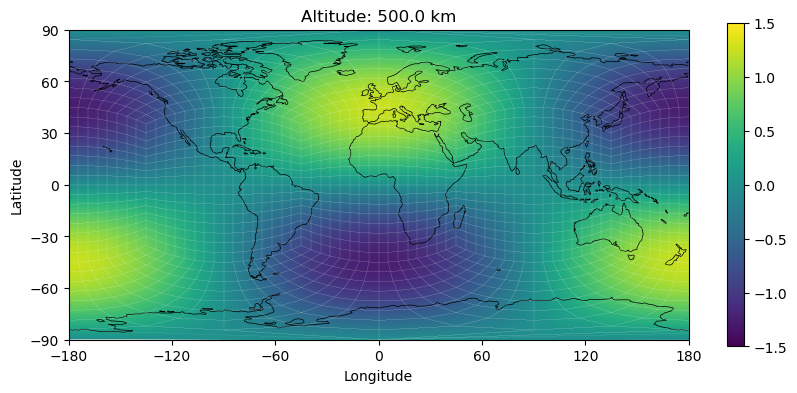

In [26]:
ilev = -1
# xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(xdg,sol[:,0,:,-1],master,ilev)
xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(xdg,vdg[:,0,:],master,ilev)
fig, ax = PlotUtilities.plotslice(xcg2d,ucg2d, xgrid, coastlines=True, clim=(-1.5,1.5), coastcolor='k', coastlw=0.5, color='w', lw=0.05)
ax.set_title(f'Altitude: {(altitude*H0 - Re)/1000:.1f} km')